In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

df=pd.read_csv("JD_SNOTEL_2014.csv")


C:\Users\gretchenhough\AppData\Local\Temp\ipykernel_20504\2907128591.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("JD_SNOTEL_2014.csv")


In [2]:
df=df.drop(columns=["Site Id"])
df["Date"]=pd.to_datetime(df["Date"])

df=df.replace([-9999, -99.9], np.nan)

In [3]:
# Data clean-up. Get rid of negative precip, calculate hourly precip from cumulative precip at SNOTEL site.

df=df.dropna(subset=["Date"])
df["P_124b_mm"]=df["P_124b_mm"].clip(lower=0)
df["P_125_mm"]=df["P_125_mm"].clip(lower=0)
df["z_s_ST_in"]=df["z_s_ST_in"].clip(lower=0)
df.loc[df["z_s_ST_in"]>20, "z_s_ST_in"] = np.nan # Lots of 79 or 80 inches in between 1-10 inch cells when SWE is still around 1. Clearly these are bad data.

In [4]:
# Converting to mm for consistency (because precip is in mm).

df["SWE_ST_mm"]=df["SWE_ST_in"]*25.4
df["z_s_ST_mm"]=df["z_s_ST_in"]*25.4
df["z_s_124b_mm"]=df["z_s_124b_cm"]*10
df["z_s_jdt4_mm"]=df["z_s_jdt4_cm"]*10
df["z_s_jdt3_mm"]=df["z_s_jdt3_cm"]*10
df["z_s_jdt2_mm"]=df["z_s_jdt2_cm"]*10
df["z_s_jdt1_mm"]=df["z_s_jdt1_cm"]*10
df["z_s_125_mm"]=df["z_s_125_cm"]*10
df["z_s_jdt4b_mm"]=df["z_s_jdt4b_cm"]*10
df["z_s_jdt3b_mm"]=df["z_s_jdt3b_cm"]*10
df["z_s_jdt2b_mm"]=df["z_s_jdt2b_cm"]*10


In [5]:
#Ewwww there were a lot of bad values in snow depth at the SNOTEL. I'm interpolating SWE and snow depth for the SNOTEL before I run computations (only over 6 hours max, otherwise still NaN for longer bad data)
df["SWE_ST_mm_clean"]=df["SWE_ST_mm"].copy()
df["z_s_ST_mm_clean"]=df["z_s_ST_mm"].copy()
df["SWE_ST_mm_interp"]=df["SWE_ST_mm_clean"].interpolate(limit=6)
df["z_s_ST_mm_interp"]=df["z_s_ST_mm_clean"].interpolate(limit=6)

In [6]:
# Using linear interpolation to get after snow fraction and precip amount at intermediate sites based on elevation from Google Earth (in meters).

z_124b=1779.77
z_125=1508.53
z_jdt4=1705.68
z_jdt3=1658.57
z_jdt2=1613.17
z_jdt1=1553.02
z_jdt2b=1614.89
z_jdt3b=1661.06
z_jdt4b=1706.54


#Snow fraction
df["f_s_jdt4"]=df["f_s_125"]+((z_jdt4-z_125)/(z_124b-z_125))*(df["f_s_124b"]-df["f_s_125"])
df["f_s_jdt3"]=df["f_s_125"]+((z_jdt3-z_125)/(z_124b-z_125))*(df["f_s_124b"]-df["f_s_125"])
df["f_s_jdt2"]=df["f_s_125"]+((z_jdt2-z_125)/(z_124b-z_125))*(df["f_s_124b"]-df["f_s_125"])
df["f_s_jdt1"]=df["f_s_125"]+((z_jdt1-z_125)/(z_124b-z_125))*(df["f_s_124b"]-df["f_s_125"])
df["f_s_jdt4b"]=df["f_s_125"]+((z_jdt4b-z_125)/(z_124b-z_125))*(df["f_s_124b"]-df["f_s_125"])
df["f_s_jdt3b"]=df["f_s_125"]+((z_jdt3b-z_125)/(z_124b-z_125))*(df["f_s_124b"]-df["f_s_125"])
df["f_s_jdt2b"]=df["f_s_125"]+((z_jdt2b-z_125)/(z_124b-z_125))*(df["f_s_124b"]-df["f_s_125"])

#Precip (mm)
df["P_jdt4_mm"]=df["P_125_mm"]+((z_jdt4-z_125)/(z_124b-z_125))*(df["P_124b_mm"]-df["P_125_mm"])
df["P_jdt3_mm"]=df["P_125_mm"]+((z_jdt3-z_125)/(z_124b-z_125))*(df["P_124b_mm"]-df["P_125_mm"])
df["P_jdt2_mm"]=df["P_125_mm"]+((z_jdt2-z_125)/(z_124b-z_125))*(df["P_124b_mm"]-df["P_125_mm"])
df["P_jdt1_mm"]=df["P_125_mm"]+((z_jdt1-z_125)/(z_124b-z_125))*(df["P_124b_mm"]-df["P_125_mm"])
df["P_jdt4b_mm"]=df["P_125_mm"]+((z_jdt4b-z_125)/(z_124b-z_125))*(df["P_124b_mm"]-df["P_125_mm"])
df["P_jdt3b_mm"]=df["P_125_mm"]+((z_jdt3b-z_125)/(z_124b-z_125))*(df["P_124b_mm"]-df["P_125_mm"])
df["P_jdt2b_mm"]=df["P_125_mm"]+((z_jdt2b-z_125)/(z_124b-z_125))*(df["P_124b_mm"]-df["P_125_mm"])

print(df.columns)

Index(['Date', 'Time', 'SWE_ST_in', 'z_s_ST_in', 'SM__ST_2in', 'SM_ST_4in',
       'SM_ST_8in', 'SM_ST_20in', 'SM_ST_40in', 'z_s_124b_cm',
       ...
       'f_s_jdt4b', 'f_s_jdt3b', 'f_s_jdt2b', 'P_jdt4_mm', 'P_jdt3_mm',
       'P_jdt2_mm', 'P_jdt1_mm', 'P_jdt4b_mm', 'P_jdt3b_mm', 'P_jdt2b_mm'],
      dtype='object', length=109)


In [7]:
# Need to calculate rainfall at each site (instantaneous contribution to surface water input SWI)

df["rain_124b_mm"]=df["P_124b_mm"]*(1-df["f_s_124b"])
df["rain_125_mm"]=df["P_125_mm"]*(1-df["f_s_125"])
df["rain_jdt4_mm"]=df["P_jdt4_mm"]*(1-df["f_s_jdt4"])
df["rain_jdt3_mm"]=df["P_jdt3_mm"]*(1-df["f_s_jdt3"])
df["rain_jdt2_mm"]=df["P_jdt2_mm"]*(1-df["f_s_jdt2"])
df["rain_jdt1_mm"]=df["P_jdt1_mm"]*(1-df["f_s_jdt1"])
df["rain_jdt4b_mm"]=df["P_jdt4b_mm"]*(1-df["f_s_jdt4b"])
df["rain_jdt3b_mm"]=df["P_jdt3b_mm"]*(1-df["f_s_jdt3b"])
df["rain_jdt2b_mm"]=df["P_jdt2b_mm"]*(1-df["f_s_jdt2b"])

In [8]:
df_daily=df.resample("D", on="Date").agg({
    # SWE daily mean
    "SWE_ST_mm_interp": "mean",

    #Snow depth daily mean
    "z_s_ST_mm_interp": "mean",
    "z_s_124b_mm": "mean",
    "z_s_125_mm": "mean",
    "z_s_jdt4_mm": "mean",
    "z_s_jdt3_mm": "mean",
    "z_s_jdt2_mm": "mean",
    "z_s_jdt1_mm": "mean",
    "z_s_jdt4b_mm": "mean",
    "z_s_jdt3b_mm": "mean",
    "z_s_jdt2b_mm": "mean",

    # Precip as total daily input
    "P_124b_mm": "sum",
    "P_125_mm": "sum",
    "P_jdt4_mm": "sum",
    "P_jdt3_mm": "sum",
    "P_jdt2_mm" : "sum",
    "P_jdt1_mm" : "sum",
    "P_jdt4b_mm": "sum",
    "P_jdt3b_mm": "sum",
    "P_jdt2b_mm" : "sum",

    # rain as total daily input
    "rain_124b_mm": "sum",
    "rain_125_mm": "sum",
    "rain_jdt4_mm": "sum",
    "rain_jdt3_mm": "sum",
    "rain_jdt2_mm": "sum",
    "rain_jdt1_mm": "sum",
    "rain_jdt4b_mm": "sum",
    "rain_jdt3b_mm": "sum",
    "rain_jdt2b_mm": "sum",

    # soil moisture as daily average
    "SM__ST_2in": "mean",
    "SM_ST_4in": "mean",
    "SM_ST_8in": "mean",
    "SM_ST_20in": "mean",
    "SM_ST_40in": "mean",
    "SM_124b_5cm": "mean",
    "SM_124b_20cm": "mean",
    "SM_124b_50cm": "mean",
    "SM_124b_75cm": "mean",
    "SM_124b_90cm": "mean",
    "SM_jdt4_5cm": "mean",
    "SM_jdt4_20cm": "mean",
    "SM_jdt4_50cm": "mean",
    "SM_jdt4_75cm": "mean",
    "SM_jdt4_100cm": "mean",
    "SM_jdt3_5cm": "mean",
    "SM_jdt3_20cm": "mean",
    "SM_jdt3_50cm": "mean",
    "SM_jdt3_75cm": "mean",
    "SM_jdt3_100cm": "mean",
    "SM_jdt2_5cm": "mean",
    "SM_jdt2_20cm": "mean",
    "SM_jdt2_50cm": "mean",
    "SM_jdt2_75cm": "mean",
    "SM_jdt2_100cm": "mean",
    "SM_jdt1_5cm": "mean",
    "SM_jdt1_20cm": "mean",
    "SM_jdt1_50cm": "mean",
    "SM_jdt1_90cm": "mean",
    "SM_jdt1_130cm": "mean",
    "SM_jdt1_190cm": "mean",
    "SM_jdt4b_5cm": "mean",
    "SM_jdt4b_20cm": "mean",
    "SM_jdt4b_35cm": "mean",
    "SM_jdt4b_50cm": "mean",
    "SM_jdt3b_5cm": "mean",
    "SM_jdt3b_20cm": "mean",
    "SM_jdt3b_35cm": "mean",
    "SM_jdt3b_50cm": "mean",
    "SM_jdt2b_5cm": "mean",
    "SM_jdt2b_20cm": "mean",
    "SM_jdt2b_35cm": "mean",
    "SM_jdt2b_50cm": "mean",
    "SM_jdt2b_75cm": "mean",

}).reset_index()

In [9]:
#Hourly cumulative precip was so messed up at SNOTEL. Daily has been corrected by SNOTEL, so I'm merging that (CP_ST_in) now with my df_daily along with relative humidity (RH_ST) and average daily temp (T_ST_C).

df_st = pd.read_csv("ST_Daily_Corrected.csv")

In [10]:
df_st["Date"] = pd.to_datetime(df_st["Date"])
df_daily["Date"] = pd.to_datetime(df_daily["Date"])

df_daily = df_daily.merge(df_st, on="Date", how="left")

print(df_daily.columns)


Index(['Date', 'SWE_ST_mm_interp', 'z_s_ST_mm_interp', 'z_s_124b_mm',
       'z_s_125_mm', 'z_s_jdt4_mm', 'z_s_jdt3_mm', 'z_s_jdt2_mm',
       'z_s_jdt1_mm', 'z_s_jdt4b_mm', 'z_s_jdt3b_mm', 'z_s_jdt2b_mm',
       'P_124b_mm', 'P_125_mm', 'P_jdt4_mm', 'P_jdt3_mm', 'P_jdt2_mm',
       'P_jdt1_mm', 'P_jdt4b_mm', 'P_jdt3b_mm', 'P_jdt2b_mm', 'rain_124b_mm',
       'rain_125_mm', 'rain_jdt4_mm', 'rain_jdt3_mm', 'rain_jdt2_mm',
       'rain_jdt1_mm', 'rain_jdt4b_mm', 'rain_jdt3b_mm', 'rain_jdt2b_mm',
       'SM__ST_2in', 'SM_ST_4in', 'SM_ST_8in', 'SM_ST_20in', 'SM_ST_40in',
       'SM_124b_5cm', 'SM_124b_20cm', 'SM_124b_50cm', 'SM_124b_75cm',
       'SM_124b_90cm', 'SM_jdt4_5cm', 'SM_jdt4_20cm', 'SM_jdt4_50cm',
       'SM_jdt4_75cm', 'SM_jdt4_100cm', 'SM_jdt3_5cm', 'SM_jdt3_20cm',
       'SM_jdt3_50cm', 'SM_jdt3_75cm', 'SM_jdt3_100cm', 'SM_jdt2_5cm',
       'SM_jdt2_20cm', 'SM_jdt2_50cm', 'SM_jdt2_75cm', 'SM_jdt2_100cm',
       'SM_jdt1_5cm', 'SM_jdt1_20cm', 'SM_jdt1_50cm', 'SM_jdt1_90cm',
  

In [11]:
# I am using Dingman 2015 to calculate e* from temp, then ea from RH and e*, then dew point temp Td from ea. I need this to calculate snow fraction with the same method as snow fraction at 124b and 125.

df_daily["RH_ST"] = df_daily["RH_ST"].clip(1,100)
df_daily["es_ST_Pa"] = 611*np.exp((17.27*df_daily["T_ST_C"])/(df_daily["T_ST_C"]+237.3))
df_daily["ea_ST_Pa"] = df_daily["RH_ST"]*df_daily["es_ST_Pa"]
df_daily["Td_ST_C"] = (np.log(df_daily["ea_ST_Pa"])-6.415) / (0.0999-(0.00421*np.log(df_daily["ea_ST_Pa"])))

In [12]:
# Snow fraction calculated for SNOTEL based on Marks et al. 2013 approach (same as applied at 124b and 125).

df_daily["f_s_ST"] = np.nan
for i in range(len(df_daily["Td_ST_C"])):
    if df_daily.loc[i, "Td_ST_C"] < -0.5:
        df_daily.loc[i, "f_s_ST"] = 1.0
    elif df_daily.loc[i, "Td_ST_C"] >= -0.5 and df_daily.loc[i, "Td_ST_C"] < 0.0:
        df_daily.loc[i, "f_s_ST"] = (((-df_daily.loc[i, "Td_ST_C"]/0.5)*0.25) + 0.75)
    elif df_daily.loc[i, "Td_ST_C"] >= 0.0 and df_daily.loc[i, "Td_ST_C"] < 0.5:
        df_daily.loc[i, "f_s_ST"] = (((-df_daily.loc[i, "Td_ST_C"]/1.0)*0.75) + 0.75)
    elif df_daily.loc[i, "Td_ST_C"] >= 0.5:
        df_daily.loc[i, "f_s_ST"] = 0.0

In [13]:
df_daily["P_ST_in"] = df_daily["CP_ST_in"].diff()
df_daily["P_ST_mm"] = df_daily["P_ST_in"]*25.4
df_daily["rain_ST_mm"] = df_daily["P_ST_mm"]*(1-df_daily["f_s_ST"])

In [14]:
# Computing snow bulk desnity fraction from SNOTEL site to apply as a rough adjustment from snowdepth to SWE at Johnston Draw sites.

df_daily["rho"]=df_daily["SWE_ST_mm_interp"]/df_daily["z_s_ST_mm_interp"]

# kill bad physics
df_daily.loc[df_daily["z_s_ST_mm_interp"] <= 0, "rho"] = np.nan
df_daily.loc[df_daily["SWE_ST_mm_interp"]<=0, "rho"] = np.nan
df_daily.loc[df_daily["rho"] < 0, "rho"] = np.nan
df_daily.loc[df_daily["rho"]>1.0, "rho"]=np.nan

df_daily["rho"].describe(percentiles=[0.90,0.95,0.99])

count    110.000000
mean       0.481329
std        0.252781
min        0.066667
50%        0.479901
90%        0.800000
95%        0.886304
99%        0.959910
max        0.984783
Name: rho, dtype: float64

In [15]:
# Man there are some big gaps in rho during spring melt. 
# I need more interpolation to get SWE at my other sites. 
# The melt phase on N-facing slopes is otherwise NaN. And the snow depth data exists, so I just need a rho value to carry forward. 
# These got nuked because the SNOTEL site had faulty snow depth values for a lot of days in that time.

df_daily["rho_fill"]=df_daily["rho"].copy()
mask = (df_daily["Date"] >= "2014-01-01") & (df_daily["Date"] <= "2014-03-31")
df_daily.loc[mask, "rho_fill"] = df_daily.loc[mask, "rho_fill"].ffill(limit=15).bfill(limit=3)

In [16]:
# Need dialy SWE at each site

df_daily["SWE_124b_mm"]=df_daily["z_s_124b_mm"]*df_daily["rho_fill"]
df_daily["SWE_125_mm"]=df_daily["z_s_125_mm"]*df_daily["rho_fill"]
df_daily["SWE_jdt4_mm"]=df_daily["z_s_jdt4_mm"]*df_daily["rho_fill"]
df_daily["SWE_jdt3_mm"]=df_daily["z_s_jdt3_mm"]*df_daily["rho_fill"]
df_daily["SWE_jdt2_mm"]=df_daily["z_s_jdt2_mm"]*df_daily["rho_fill"]
df_daily["SWE_jdt1_mm"]=df_daily["z_s_jdt1_mm"]*df_daily["rho_fill"]
df_daily["SWE_jdt4b_mm"]=df_daily["z_s_jdt4b_mm"]*df_daily["rho_fill"]
df_daily["SWE_jdt3b_mm"]=df_daily["z_s_jdt3b_mm"]*df_daily["rho_fill"]
df_daily["SWE_jdt2b_mm"]=df_daily["z_s_jdt2b_mm"]*df_daily["rho_fill"]

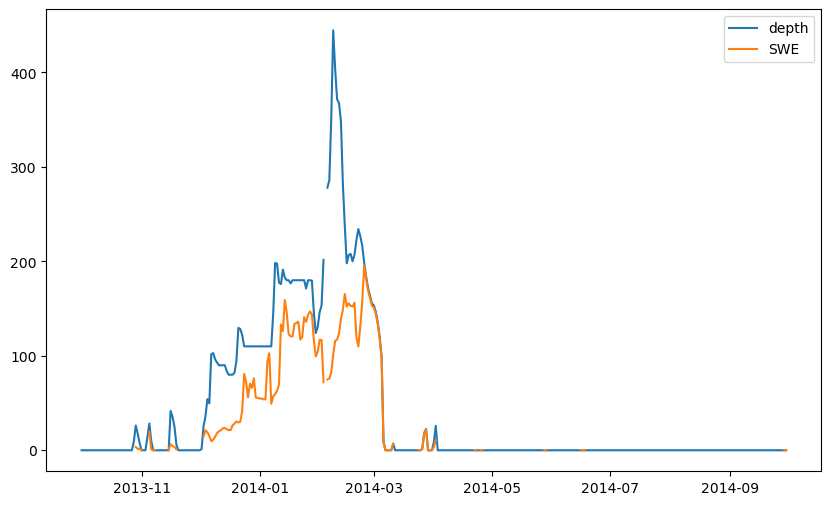

In [17]:
fig,axes=plt.subplots(figsize=(10,6))

axes.plot(df_daily["Date"],df_daily['z_s_jdt4_mm'], label="depth")
axes.plot(df_daily["Date"], df_daily["SWE_jdt4_mm"], label="SWE")
axes.legend()
plt.show()

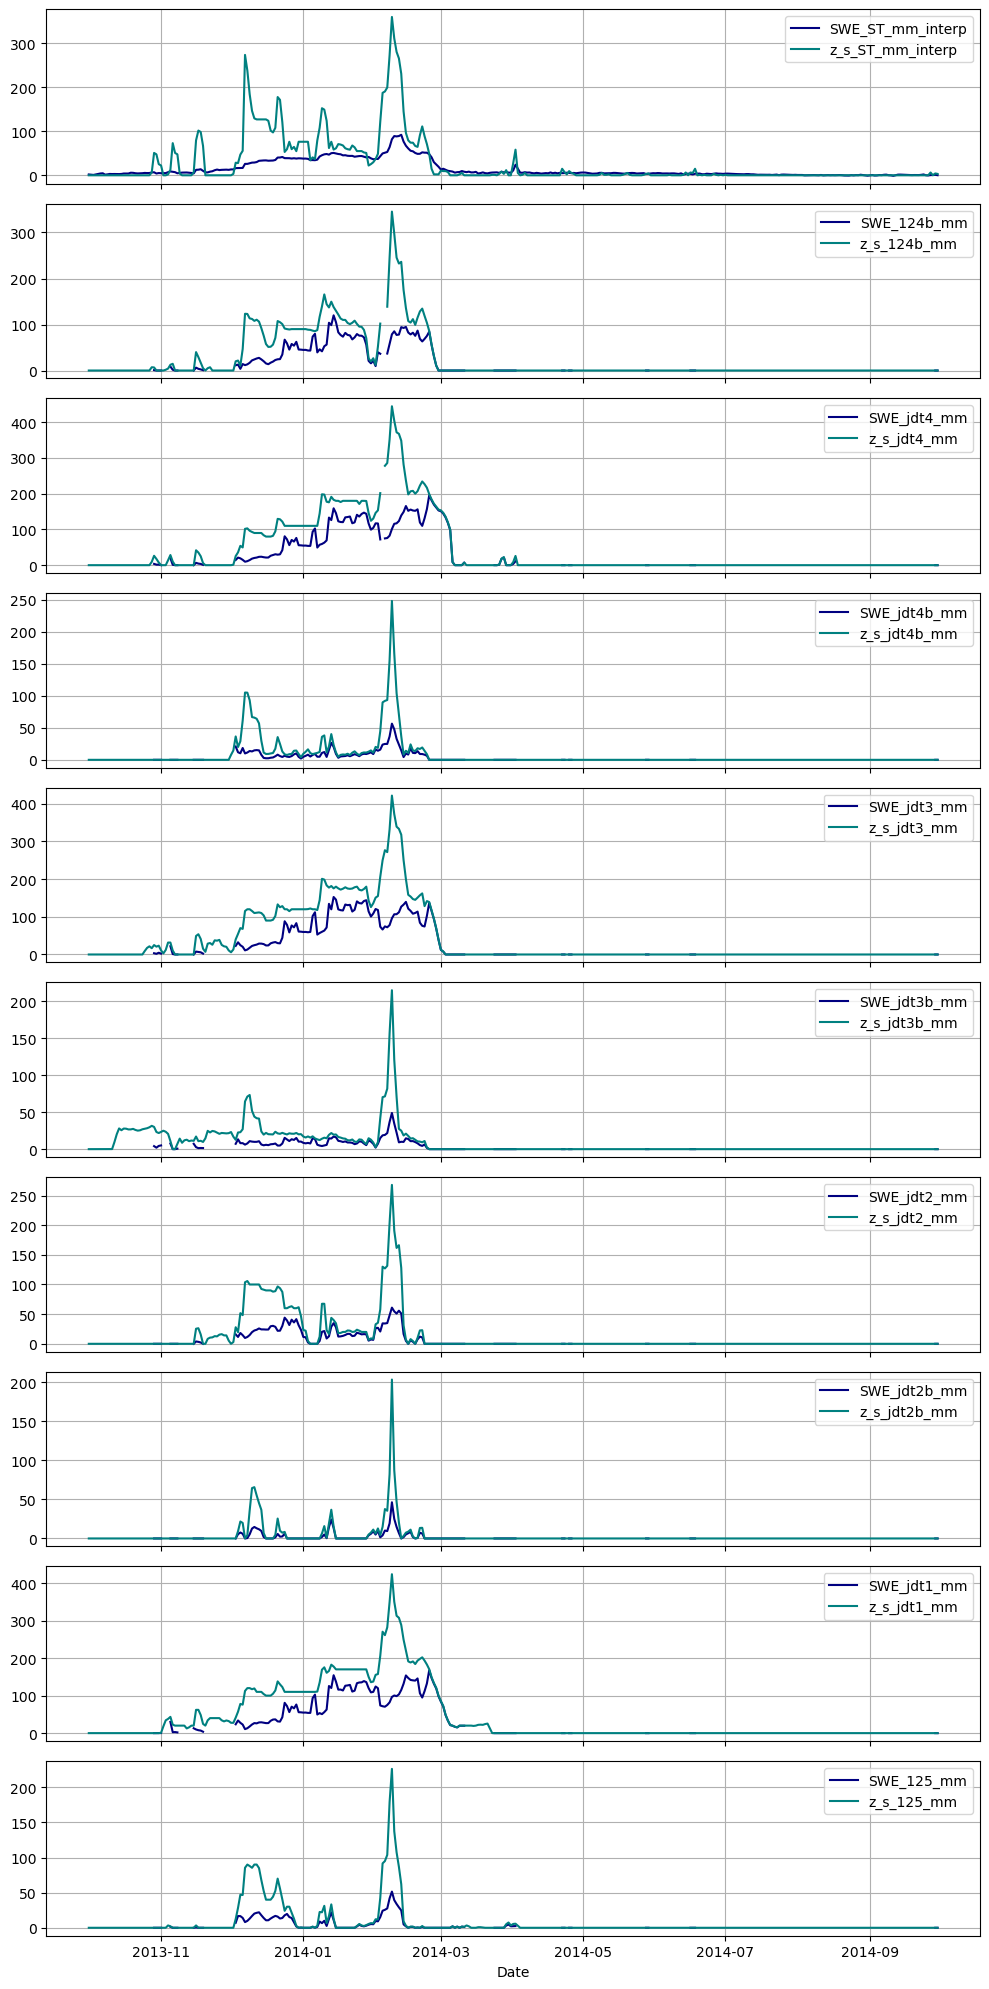

In [18]:
swe_cols = [
    "SWE_ST_mm_interp",
    "SWE_124b_mm",
    "SWE_jdt4_mm",
    "SWE_jdt4b_mm",
    "SWE_jdt3_mm",
    "SWE_jdt3b_mm",
    "SWE_jdt2_mm",
    "SWE_jdt2b_mm",
    "SWE_jdt1_mm",
    "SWE_125_mm"
]

z_cols = ["z_s_ST_mm_interp", 
        "z_s_124b_mm",
        "z_s_jdt4_mm",
        "z_s_jdt4b_mm",
        "z_s_jdt3_mm",
        "z_s_jdt3b_mm",
        "z_s_jdt2_mm",
        "z_s_jdt2b_mm",
        "z_s_jdt1_mm",
        "z_s_125_mm"
         ]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=10, ncols=1, figsize=(10, 20), sharex=True)

for i, (swe_col, z_col) in enumerate(zip(swe_cols, z_cols)):
    axes[i].plot(df_daily["Date"], df_daily[swe_col], color="navy", label=swe_col)
    axes[i].plot(df_daily["Date"], df_daily[z_col], color="teal", label=z_col)
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

In [19]:
# Smoothing data gaps with linear interpolation in SWE

swe_cols = [
    "SWE_ST_mm_interp",
    "SWE_124b_mm",
    "SWE_125_mm",
    "SWE_jdt4_mm",
    "SWE_jdt3_mm",
    "SWE_jdt2_mm",
    "SWE_jdt1_mm",
    "SWE_jdt4b_mm",
    "SWE_jdt3b_mm",
    "SWE_jdt2b_mm"
]

df_daily[swe_cols] = df_daily[swe_cols].interpolate(
    method="linear",
    limit=3,
    limit_direction="both"
)


In [20]:
# Now I'm ready to calculate melt. First I need the threshold. I'm basing this on snow depth measurment instrument error of +/- 10 mm. That multiplied by rho for the SWE error, and then doubled for a reasonable cutoff to capture other noise.

df_daily["tau"]=2*df_daily["rho"]*10

# Now I need dSWE
df_daily["dSWE_ST_mm_interp"]=df_daily["SWE_ST_mm_interp"].diff()
df_daily["dSWE_124b_mm"]=df_daily["SWE_124b_mm"].diff()
df_daily["dSWE_125_mm"]=df_daily["SWE_125_mm"].diff()
df_daily["dSWE_jdt4_mm"]=df_daily["SWE_jdt4_mm"].diff()
df_daily["dSWE_jdt3_mm"]=df_daily["SWE_jdt3_mm"].diff()
df_daily["dSWE_jdt2_mm"]=df_daily["SWE_jdt2_mm"].diff()
df_daily["dSWE_jdt1_mm"]=df_daily["SWE_jdt1_mm"].diff()
df_daily["dSWE_jdt4b_mm"]=df_daily["SWE_jdt4b_mm"].diff()
df_daily["dSWE_jdt3b_mm"]=df_daily["SWE_jdt3b_mm"].diff()
df_daily["dSWE_jdt2b_mm"]=df_daily["SWE_jdt2b_mm"].diff()

# Get melt from residual dSWE
df_daily["melt_jdt4_mm"]=(-df_daily["dSWE_jdt4_mm"]).clip(lower=0)
df_daily["melt_jdt3_mm"]=(-df_daily["dSWE_jdt3_mm"]).clip(lower=0)
df_daily["melt_jdt2_mm"]=(-df_daily["dSWE_jdt2_mm"]).clip(lower=0)
df_daily["melt_jdt1_mm"]=(-df_daily["dSWE_jdt1_mm"]).clip(lower=0)
df_daily["melt_125_mm"]=(-df_daily["dSWE_125_mm"]).clip(lower=0)
df_daily["melt_124b_mm"]=(-df_daily["dSWE_124b_mm"]).clip(lower=0)
df_daily["melt_ST_mm"]=(-df_daily["dSWE_ST_mm_interp"]).clip(lower=0)
df_daily["melt_jdt4b_mm"]=(-df_daily["dSWE_jdt4b_mm"]).clip(lower=0)
df_daily["melt_jdt3b_mm"]=(-df_daily["dSWE_jdt3b_mm"]).clip(lower=0)
df_daily["melt_jdt2b_mm"]=(-df_daily["dSWE_jdt2b_mm"]).clip(lower=0)


#Get "same day" melt when precip falls as snow but disappears before measured as SWE for S-facing slopes where there is little accumulation:
df_daily["inst_melt_jdt4b_mm"]=0.0
df_daily["inst_melt_jdt3b_mm"]=0.0
df_daily["inst_melt_jdt2b_mm"]=0.0
for i in range(len(df_daily["dSWE_jdt4_mm"])):
     if df_daily.loc[i, "dSWE_jdt4b_mm"] >= 0.0 and df_daily.loc[i, "P_jdt4b_mm"] > 0.0:
        val = - df_daily.loc[i, "dSWE_jdt4b_mm"] - df_daily.loc[i, "rain_jdt4b_mm"] + df_daily.loc[i, "P_jdt4b_mm"]
        df_daily.loc[i, "inst_melt_jdt4b_mm"] = max(val, 0.0)
     if df_daily.loc[i, "dSWE_jdt3b_mm"] >= 0.0 and df_daily.loc[i, "P_jdt3b_mm"] > 0.0:
        val = - df_daily.loc[i, "dSWE_jdt3b_mm"] - df_daily.loc[i, "rain_jdt3b_mm"] + df_daily.loc[i, "P_jdt3b_mm"]
        df_daily.loc[i, "inst_melt_jdt3b_mm"] = max(val, 0.0)
     if df_daily.loc[i, "dSWE_jdt2b_mm"] >= 0.0 and df_daily.loc[i, "P_jdt2b_mm"] > 0.0:
        val = - df_daily.loc[i, "dSWE_jdt2b_mm"] - df_daily.loc[i, "rain_jdt2b_mm"] + df_daily.loc[i, "P_jdt2b_mm"]
        df_daily.loc[i, "inst_melt_jdt2b_mm"] = max(val, 0.0)

# Get rid of everything below my tau cutoff
df_daily["melt_ST_mm"] = df_daily["melt_ST_mm"].where(df_daily["melt_ST_mm"] > df_daily["tau"],0)
df_daily["melt_124b_mm"] = df_daily["melt_124b_mm"].where(df_daily["melt_124b_mm"] > df_daily["tau"],0)
df_daily["melt_125_mm"] = df_daily["melt_125_mm"].where(df_daily["melt_125_mm"] > df_daily["tau"],0)
df_daily["melt_jdt4_mm"] = df_daily["melt_jdt4_mm"].where(df_daily["melt_jdt4_mm"] > df_daily["tau"],0)
df_daily["melt_jdt3_mm"] = df_daily["melt_jdt3_mm"].where(df_daily["melt_jdt3_mm"] > df_daily["tau"],0)
df_daily["melt_jdt2_mm"] = df_daily["melt_jdt2_mm"].where(df_daily["melt_jdt2_mm"] > df_daily["tau"],0)
df_daily["melt_jdt1_mm"] = df_daily["melt_jdt1_mm"].where(df_daily["melt_jdt1_mm"] > df_daily["tau"],0)
df_daily["melt_jdt4b_mm"] = df_daily["melt_jdt4b_mm"].where(df_daily["melt_jdt4b_mm"] > df_daily["tau"],0)
df_daily["melt_jdt3b_mm"] = df_daily["melt_jdt3b_mm"].where(df_daily["melt_jdt3b_mm"] > df_daily["tau"],0)
df_daily["melt_jdt2b_mm"] = df_daily["melt_jdt2b_mm"].where(df_daily["melt_jdt2b_mm"] > df_daily["tau"],0)
df_daily["inst_melt_jdt4b_mm"] = df_daily["inst_melt_jdt4b_mm"].where(df_daily["inst_melt_jdt4b_mm"] > df_daily["tau"],0)
df_daily["inst_melt_jdt3b_mm"] = df_daily["inst_melt_jdt3b_mm"].where(df_daily["inst_melt_jdt3b_mm"] > df_daily["tau"],0)
df_daily["inst_melt_jdt2b_mm"] = df_daily["inst_melt_jdt2b_mm"].where(df_daily["inst_melt_jdt2b_mm"] > df_daily["tau"],0)

# And now final SWI
df_daily["SWI_ST_mm"]=df_daily["melt_ST_mm"]+df_daily["rain_ST_mm"]
df_daily["SWI_124b_mm"]=df_daily["melt_124b_mm"]+df_daily["rain_124b_mm"]
df_daily["SWI_125_mm"]=df_daily["melt_125_mm"]+df_daily["rain_125_mm"]
df_daily["SWI_jdt4_mm"]=df_daily["melt_jdt4_mm"]+df_daily["rain_jdt4_mm"]
df_daily["SWI_jdt3_mm"]=df_daily["melt_jdt3_mm"]+df_daily["rain_jdt3_mm"]
df_daily["SWI_jdt2_mm"]=df_daily["melt_jdt2_mm"]+df_daily["rain_jdt2_mm"]
df_daily["SWI_jdt1_mm"]=df_daily["melt_jdt1_mm"]+df_daily["rain_jdt1_mm"]
df_daily["SWI_jdt4b_mm"]=df_daily["melt_jdt4b_mm"]+df_daily["rain_jdt4b_mm"]+df_daily["inst_melt_jdt4b_mm"]
df_daily["SWI_jdt3b_mm"]=df_daily["melt_jdt3b_mm"]+df_daily["rain_jdt3b_mm"]+df_daily["inst_melt_jdt3b_mm"]
df_daily["SWI_jdt2b_mm"]=df_daily["melt_jdt2b_mm"]+df_daily["rain_jdt2b_mm"]+df_daily["inst_melt_jdt2b_mm"]

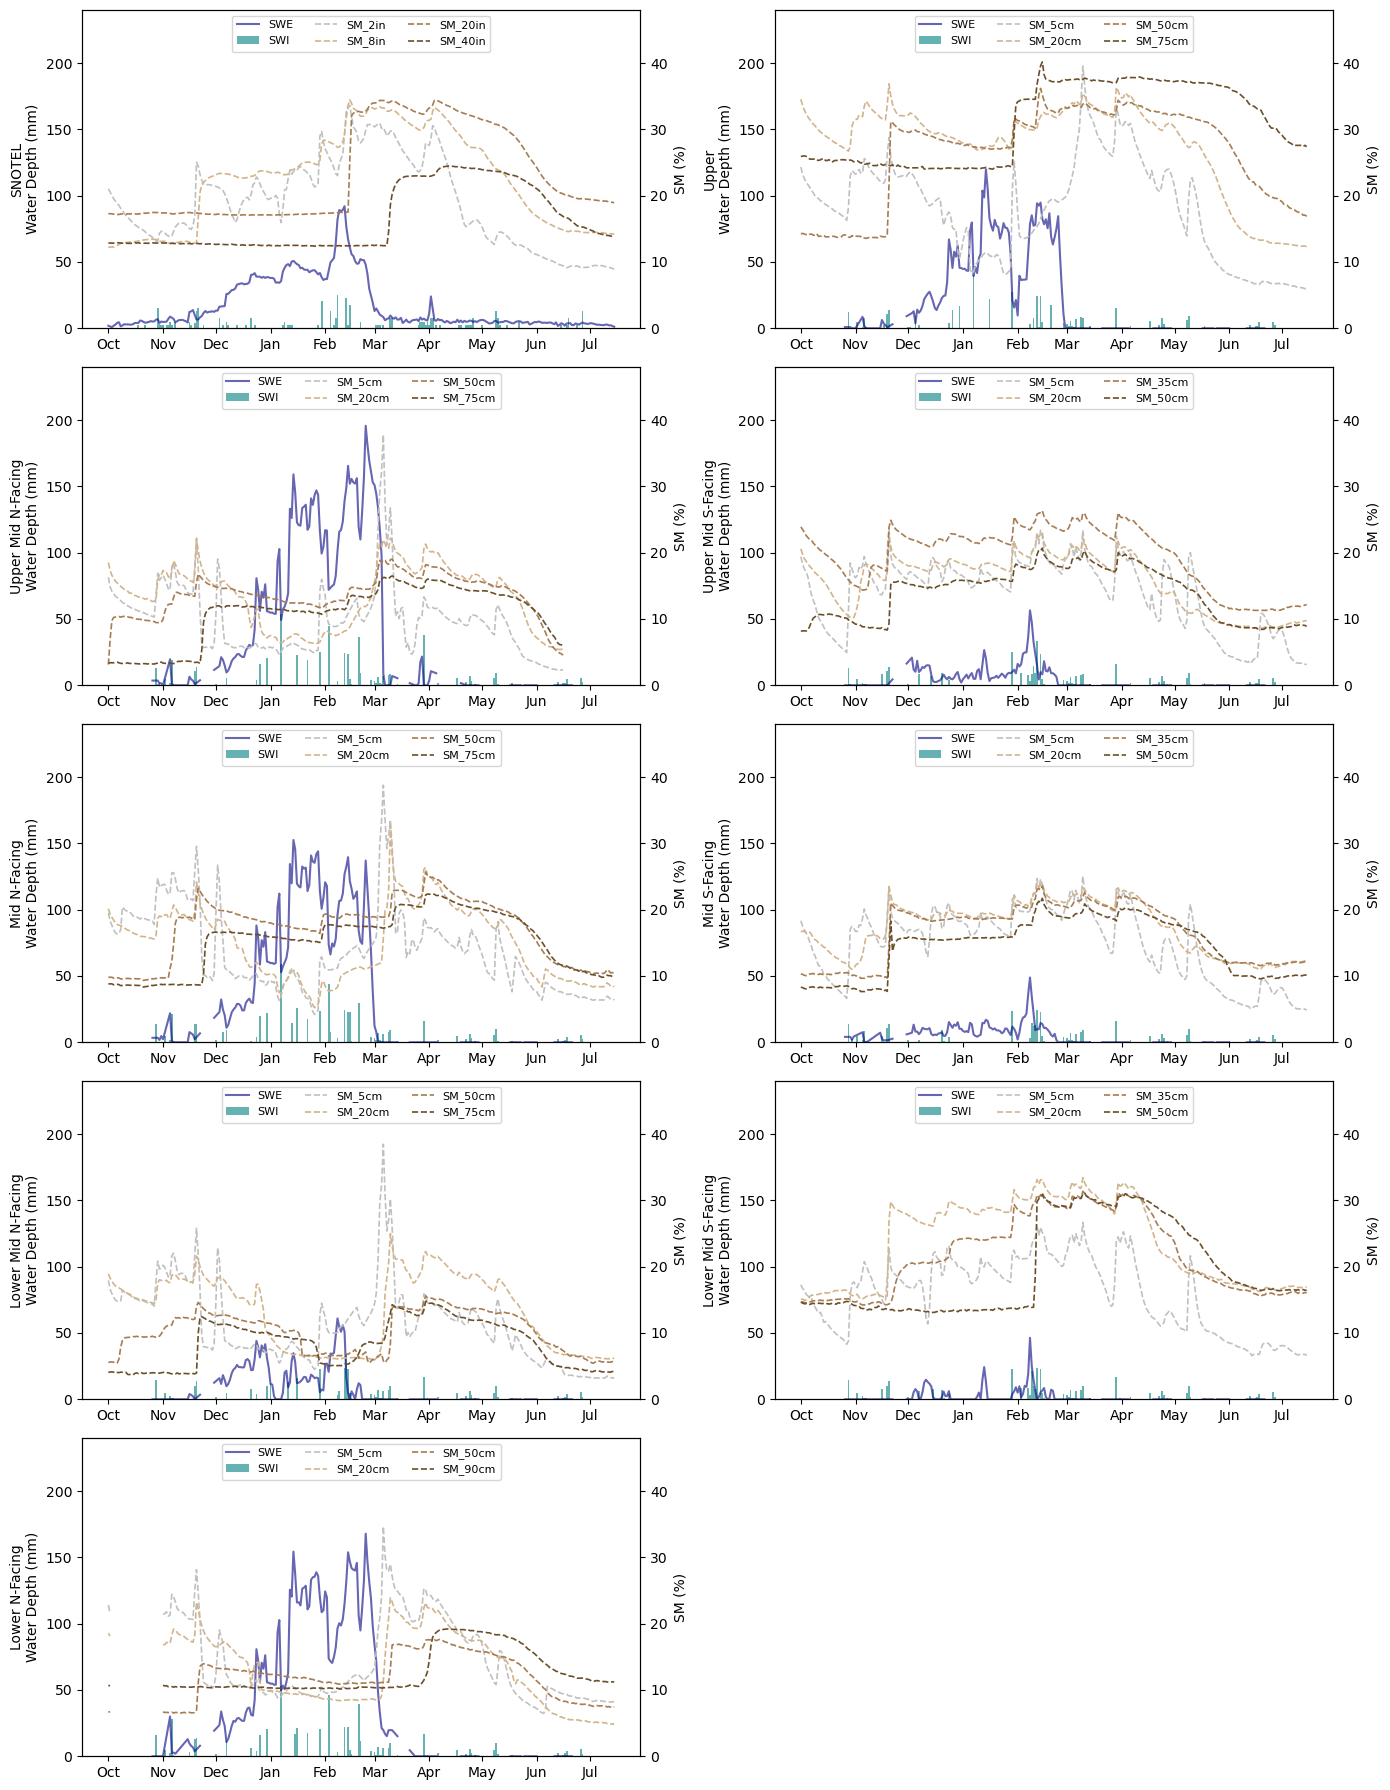

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math

# ---------- Map each site to its SWI column and soil moisture columns ----------
site_info = {
    "ST": {"name":"SNOTEL",
        "swi": "SWI_ST_mm",
        "swe" : "SWE_ST_mm_interp",
        "sm": ["SM__ST_2in","SM_ST_8in", "SM_ST_20in", "SM_ST_40in"]
    },
    "124b": {"name":"Upper",
        "swi": "SWI_124b_mm",
        "swe": "SWE_124b_mm",
        "sm": ["SM_124b_5cm","SM_124b_20cm", "SM_124b_50cm", "SM_124b_75cm"]
    },
    "jdt4": {"name":"Upper Mid N-Facing",
        "swi": "SWI_jdt4_mm",
        "swe": "SWE_jdt4_mm",
        "sm": ["SM_jdt4_5cm","SM_jdt4_20cm", "SM_jdt4_50cm", "SM_jdt4_75cm"]
    },
    "jdt4b": {"name":"Upper Mid S-Facing",
        "swi": "SWI_jdt4b_mm",
        "swe": "SWE_jdt4b_mm",
        "sm": ["SM_jdt4b_5cm","SM_jdt4b_20cm", "SM_jdt4b_35cm", "SM_jdt4b_50cm"]
    },
    "jdt3": {"name":"Mid N-Facing",
        "swi": "SWI_jdt3_mm",
        "swe": "SWE_jdt3_mm",
        "sm": ["SM_jdt3_5cm","SM_jdt3_20cm", "SM_jdt3_50cm", "SM_jdt3_75cm"]
    },
    "jdt3b": {"name":"Mid S-Facing",
        "swi": "SWI_jdt3b_mm",
        "swe": "SWE_jdt3b_mm",
        "sm": ["SM_jdt3b_5cm","SM_jdt3b_20cm", "SM_jdt3b_35cm", "SM_jdt3b_50cm"]
    },
    "jdt2": {"name":"Lower Mid N-Facing",
        "swi": "SWI_jdt2_mm",
        "swe": "SWE_jdt2_mm",
        "sm": ["SM_jdt2_5cm","SM_jdt2_20cm", "SM_jdt2_50cm", "SM_jdt2_75cm"]
    },
    "jdt2b": {"name":"Lower Mid S-Facing",
        "swi": "SWI_jdt2b_mm",
        "swe": "SWE_jdt2b_mm",
        "sm": ["SM_jdt2b_5cm","SM_jdt2b_20cm", "SM_jdt2b_35cm", "SM_jdt2b_50cm"]
    },
    "jdt1": {"name":"Lower N-Facing",
        "swi": "SWI_jdt1_mm",
        "swe": "SWE_jdt1_mm",
        "sm": ["SM_jdt1_5cm","SM_jdt1_20cm", "SM_jdt1_50cm", "SM_jdt1_90cm"]
    }
}

# soil colors
sm_color = ["silver", "tan", "#a67c52", "#6b4f2a"]

# ---- crop data ----
df_plot = df_daily[
    (df_daily["Date"] >= "2013-10-01") &
    (df_daily["Date"] <= "2014-07-15")
]

# ---- plotting ----
n_sites = len(site_info)
ncols = 2
nrows = math.ceil(n_sites / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 18), sharex=True)
axes = axes.flatten()   # turn 2D array of axes into a simple 1D list

for ax, (site, info) in zip(axes, site_info.items()):
    name = info["name"]
    swi_col = info["swi"]
    swe_col = info["swe"]
    sm_cols = info["sm"]

    # SWI bars + SWE line
    ax.bar(df_plot["Date"], df_plot[swi_col], color="teal", width=1.0, alpha=0.6, label="SWI")
    ax.plot(df_plot["Date"], df_plot[swe_col], color="navy", alpha=0.6, label="SWE")
    ax.set_ylabel(f"{name}\nWater Depth (mm)")
    ax.set_ylim(0, 240)

    ax2 = ax.twinx()

    for i, col in enumerate(sm_cols):
        if site == "ST":
            sm_plot = df_plot[col]
        else:
            sm_plot = df_plot[col] * 100

        depth = col.split("_")[-1]
        color = sm_color[min(i, len(sm_color)-1)]

        ax2.plot(
            df_plot["Date"],
            sm_plot,
            color=color,
            linestyle="--",
            linewidth=1.2,
            alpha=1,
            zorder=10,
            label=f"SM_{depth}"
        )

    ax2.set_ylim(0, 48)
    ax2.set_ylabel("SM (%)")

    # combine legends
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, loc="upper center", fontsize=8, ncol=3)

    # date formatting
    ax.tick_params(labelbottom=True)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# turn off any unused empty panel(s)
for ax in axes[n_sites:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

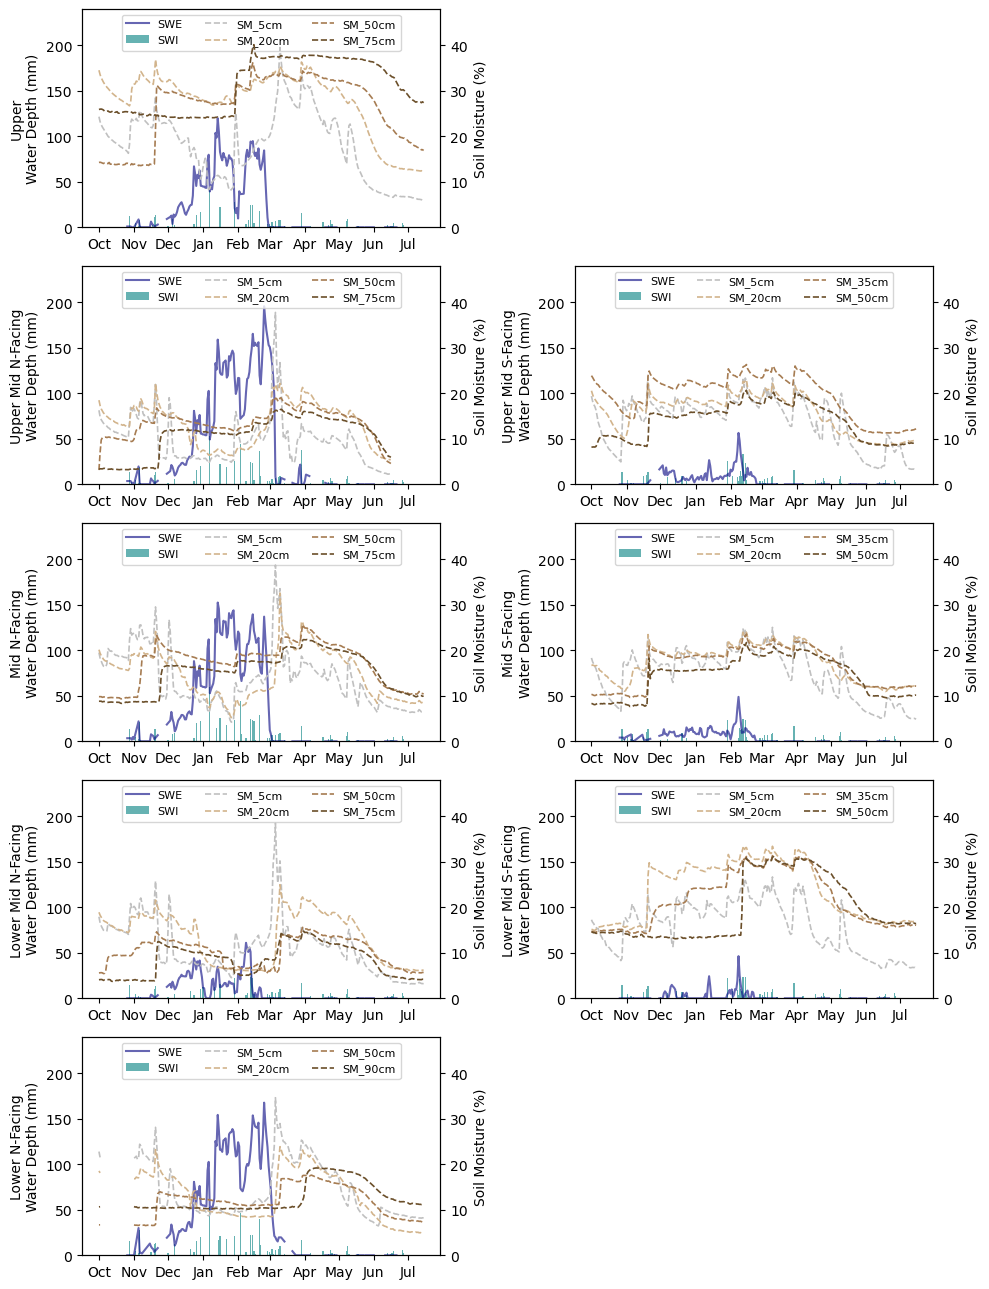

In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- Map each site to its SWI column and soil moisture columns ----------
site_info = {
    "ST": {"name":"SNOTEL",
        "swi": "SWI_ST_mm",
        "swe" : "SWE_ST_mm_interp",
        "sm": ["SM__ST_2in","SM_ST_8in", "SM_ST_20in", "SM_ST_40in"]
    },
    "124b": {"name":"Upper",
        "swi": "SWI_124b_mm",
        "swe": "SWE_124b_mm",
        "sm": ["SM_124b_5cm","SM_124b_20cm", "SM_124b_50cm", "SM_124b_75cm"]
    },
    "jdt4": {"name":"Upper Mid N-Facing",
        "swi": "SWI_jdt4_mm",
        "swe": "SWE_jdt4_mm",
        "sm": ["SM_jdt4_5cm","SM_jdt4_20cm", "SM_jdt4_50cm", "SM_jdt4_75cm"]
    },
    "jdt4b": {"name":"Upper Mid S-Facing",
        "swi": "SWI_jdt4b_mm",
        "swe": "SWE_jdt4b_mm",
        "sm": ["SM_jdt4b_5cm","SM_jdt4b_20cm", "SM_jdt4b_35cm", "SM_jdt4b_50cm"]
    },
    "jdt3": {"name":"Mid N-Facing",
        "swi": "SWI_jdt3_mm",
        "swe": "SWE_jdt3_mm",
        "sm": ["SM_jdt3_5cm","SM_jdt3_20cm", "SM_jdt3_50cm", "SM_jdt3_75cm"]
    },
    "jdt3b": {"name":"Mid S-Facing",
        "swi": "SWI_jdt3b_mm",
        "swe": "SWE_jdt3b_mm",
        "sm": ["SM_jdt3b_5cm","SM_jdt3b_20cm", "SM_jdt3b_35cm", "SM_jdt3b_50cm"]
    },
    "jdt2": {"name":"Lower Mid N-Facing",
        "swi": "SWI_jdt2_mm",
        "swe": "SWE_jdt2_mm",
        "sm": ["SM_jdt2_5cm","SM_jdt2_20cm", "SM_jdt2_50cm", "SM_jdt2_75cm"]
    },
    "jdt2b": {"name":"Lower Mid S-Facing",
        "swi": "SWI_jdt2b_mm",
        "swe": "SWE_jdt2b_mm",
        "sm": ["SM_jdt2b_5cm","SM_jdt2b_20cm", "SM_jdt2b_35cm", "SM_jdt2b_50cm"]
    },
    "jdt1": {"name":"Lower N-Facing",
        "swi": "SWI_jdt1_mm",
        "swe": "SWE_jdt1_mm",
        "sm": ["SM_jdt1_5cm","SM_jdt1_20cm", "SM_jdt1_50cm", "SM_jdt1_90cm"]
    }
}

# soil colors
sm_color = ["silver", "tan", "#a67c52", "#6b4f2a"]

# ---- crop data ----
df_plot = df_daily[
    (df_daily["Date"] >= "2013-10-01") &
    (df_daily["Date"] <= "2014-07-15")
]

# ---- choose exact panel order ----
panel_sites = [
    "124b", None,
    "jdt4", "jdt4b",
    "jdt3", "jdt3b",
    "jdt2", "jdt2b",
    "jdt1", None
]

nrows = 5
ncols = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 13), sharex=True)
axes = axes.flatten()

for ax, site in zip(axes, panel_sites):

    # blank panel
    if site is None:
        ax.set_visible(False)
        continue

    info = site_info[site]
    name = info["name"]
    swi_col = info["swi"]
    swe_col = info["swe"]
    sm_cols = info["sm"]

    # SWI bars + SWE line
    ax.bar(df_plot["Date"], df_plot[swi_col], color="teal", width=1.0, alpha=0.6, label="SWI")
    ax.plot(df_plot["Date"], df_plot[swe_col], color="navy", alpha=0.6, label="SWE")
    ax.set_ylabel(f"{name}\nWater Depth (mm)")
    ax.set_ylim(0, 240)

    ax2 = ax.twinx()

    for i, col in enumerate(sm_cols):
        sm_plot = df_plot[col] * 100

        depth = col.split("_")[-1]
        color = sm_color[min(i, len(sm_color)-1)]

        ax2.plot(
            df_plot["Date"],
            sm_plot,
            color=color,
            linestyle="--",
            linewidth=1.2,
            alpha=1,
            zorder=10,
            label=f"SM_{depth}"
        )

    ax2.set_ylim(0, 48)
    ax2.set_ylabel("Soil Moisture (%)")

    # combine legends
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, loc="upper center", fontsize=8, ncol=3)

    # date formatting
    ax.tick_params(labelbottom=True)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

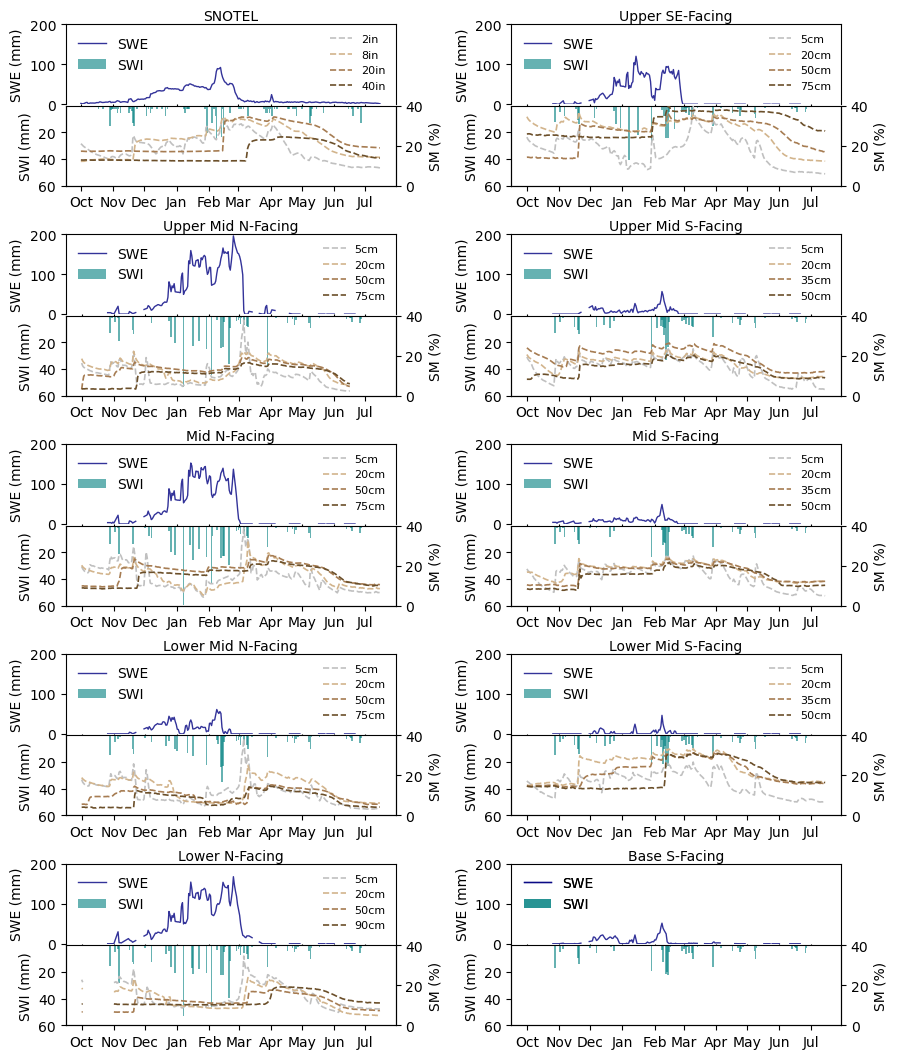

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

# ---------- Map each site to its SWI column and soil moisture columns ----------
site_info = {
    "ST": {"name":"SNOTEL",
        "swi": "SWI_ST_mm",
        "swe" : "SWE_ST_mm_interp",
        "sm": ["SM__ST_2in","SM_ST_8in", "SM_ST_20in", "SM_ST_40in"]
    },
    "124b": {"name":"Upper SE-Facing",
        "swi": "SWI_124b_mm",
        "swe": "SWE_124b_mm",
        "sm": ["SM_124b_5cm","SM_124b_20cm", "SM_124b_50cm", "SM_124b_75cm"]
    },
    "jdt4": {"name":"Upper Mid N-Facing",
        "swi": "SWI_jdt4_mm",
        "swe": "SWE_jdt4_mm",
        "sm": ["SM_jdt4_5cm","SM_jdt4_20cm", "SM_jdt4_50cm", "SM_jdt4_75cm"]
    },
    "jdt4b": {"name":"Upper Mid S-Facing",
        "swi": "SWI_jdt4b_mm",
        "swe": "SWE_jdt4b_mm",
        "sm": ["SM_jdt4b_5cm","SM_jdt4b_20cm", "SM_jdt4b_35cm", "SM_jdt4b_50cm"]
    },
    "jdt3": {"name":"Mid N-Facing",
        "swi": "SWI_jdt3_mm",
        "swe": "SWE_jdt3_mm",
        "sm": ["SM_jdt3_5cm","SM_jdt3_20cm", "SM_jdt3_50cm", "SM_jdt3_75cm"]
    },
    "jdt3b": {"name":"Mid S-Facing",
        "swi": "SWI_jdt3b_mm",
        "swe": "SWE_jdt3b_mm",
        "sm": ["SM_jdt3b_5cm","SM_jdt3b_20cm", "SM_jdt3b_35cm", "SM_jdt3b_50cm"]
    },
    "jdt2": {"name":"Lower Mid N-Facing",
        "swi": "SWI_jdt2_mm",
        "swe": "SWE_jdt2_mm",
        "sm": ["SM_jdt2_5cm","SM_jdt2_20cm", "SM_jdt2_50cm", "SM_jdt2_75cm"]
    },
    "jdt2b": {"name":"Lower Mid S-Facing",
        "swi": "SWI_jdt2b_mm",
        "swe": "SWE_jdt2b_mm",
        "sm": ["SM_jdt2b_5cm","SM_jdt2b_20cm", "SM_jdt2b_35cm", "SM_jdt2b_50cm"]
    },
    "jdt1": {"name":"Lower N-Facing",
        "swi": "SWI_jdt1_mm",
        "swe": "SWE_jdt1_mm",
        "sm": ["SM_jdt1_5cm","SM_jdt1_20cm", "SM_jdt1_50cm", "SM_jdt1_90cm"]
    },
    "125": {"name":"Base S-Facing",
        "swi": "SWI_125_mm",
        "swe": "SWE_125_mm",
        "sm": None
    }
}

sm_color = ["silver", "tan", "#a67c52", "#6b4f2a"]

df_plot = df_daily[
    (df_daily["Date"] >= "2013-10-01") &
    (df_daily["Date"] <= "2014-07-15")
].copy()

panel_sites = [
    "ST", "124b",
    "jdt4", "jdt4b",
    "jdt3", "jdt3b",
    "jdt2", "jdt2b",
    "jdt1", "125"
]

nrows = 5
ncols = 2

fig = plt.figure(figsize=(10, 13))
outer = GridSpec(nrows=nrows, ncols=ncols, figure=fig, wspace=0.35, hspace=0.3)

for i, site in enumerate(panel_sites):
    row = i // 2
    col = i % 2

    if site is None:
        continue

    info = site_info[site]
    name = info["name"]
    swi_col = info["swi"]
    swe_col = info["swe"]
    sm_cols = info["sm"]

    inner = outer[row, col].subgridspec(2, 1, height_ratios=[1, 1], hspace=0.02)

    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    # TOP: SWE
    line_swe = ax_top.plot(
        df_plot["Date"], df_plot[swe_col],
        color="navy", alpha=0.8, linewidth=1, label="SWE"
    )[0]

    ax_top.set_ylim(0, 200)
    ax_top.set_ylabel("SWE (mm)")
    ax_top.set_title(name, fontsize=10, pad=3)
    ax_top.tick_params(labelbottom=False)
    ax_top.spines["bottom"].set_visible(False)

    # BOTTOM: SWI downward
    bars_swi = ax_bot.bar(
        df_plot["Date"], df_plot[swi_col],
        color="teal", width=1.5, alpha=0.6, label="SWI"
    )

    ax_bot.invert_yaxis()
    ax_bot.set_ylim(60, 0)
    ax_bot.set_yticks([20,40,60])
    ax_bot.set_ylabel("SWI (mm)")
    ax_bot.spines["top"].set_visible(False)

    # Soil moisture on twin axis
    ax_sm = ax_bot.twinx()
    sm_lines = []

    if sm_cols is not None:
        for j, col_sm in enumerate(sm_cols):
            if site == "ST":
                sm_plot = df_plot[col_sm]      # already percent
            else:
                sm_plot = df_plot[col_sm] * 100
            depth = col_sm.split("_")[-1]
            color_sm = sm_color[min(j, len(sm_color)-1)]

            line = ax_sm.plot(
                df_plot["Date"],
                sm_plot,
                color=color_sm,
                linestyle="--",
                linewidth=1.2,
                alpha=1,
                zorder=10,
                label=depth
            )[0]
            sm_lines.append(line)

    ax_sm.set_ylim(0, 40)
    ax_sm.set_yticks([0, 20, 40])
    ax_sm.set_ylabel("SM (%)")

    ax_bot.tick_params(labelbottom=True)
    ax_bot.xaxis.set_major_locator(mdates.MonthLocator())
    ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    handles_top = [line_swe, bars_swi[0]]
    labels_top = ["SWE", "SWI"]
    leg1 = ax_top.legend(
        handles_top,
        labels_top,
        loc="upper left",
        fontsize=10,
        frameon=False
    )

    ax_top.add_artist(leg1)

    if sm_lines:
        ax_top.legend(
            sm_lines,
            [line.get_label() for line in sm_lines],
            loc="upper right",
            fontsize=8,
            frameon=False
        )

    
plt.show()

In [24]:
import pandas as pd

def T_daily_max(df, site, stat="max"):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    
    site_cols = [
        col for col in df.columns
        if col == f"Ta_{site}" or col == f"Ts_{site}" or col.startswith(f"Ts_{site}_")
    ]
    
    df_T_daily = (
        df.set_index("Date")[site_cols]
        .resample("D")
        .agg(stat)
        .reset_index()
    )
    
    rename_dict = {col: f"{col}_{stat}" for col in site_cols}
    df_T_daily = df_T_daily.rename(columns=rename_dict)
    
    return df_T_daily


sites = ["ST","124b", "jdt4", "jdt4b", "jdt3", "jdt3b", "jdt2", "jdt2b", "jdt1", "125"]

df_T_daily_max = None

for site in sites:
    T_df = T_daily_max(df, site, stat="max")
    print(site, T_df.columns.tolist())
    
    if df_T_daily_max is None:
        df_T_daily_max = T_df
    else:
        df_T_daily_max = df_T_daily_max.merge(T_df, on="Date", how="outer")

df_daily = df_daily.merge(df_T_daily_max, on="Date", how="left")

ST ['Date', 'Ta_ST_max', 'Ts_ST_max']
124b ['Date', 'Ta_124b_max', 'Ts_124b_max']
jdt4 ['Date', 'Ta_jdt4_max', 'Ts_jdt4_max']
jdt4b ['Date', 'Ta_jdt4b_max', 'Ts_jdt4b_max']
jdt3 ['Date', 'Ta_jdt3_max', 'Ts_jdt3_max']
jdt3b ['Date', 'Ta_jdt3b_max', 'Ts_jdt3b_max']
jdt2 ['Date', 'Ta_jdt2_max', 'Ts_jdt2_max']
jdt2b ['Date', 'Ta_jdt2b_max', 'Ts_jdt2b_max']
jdt1 ['Date', 'Ta_jdt1_max', 'Ts_jdt1_max']
125 ['Date', 'Ta_125_max']


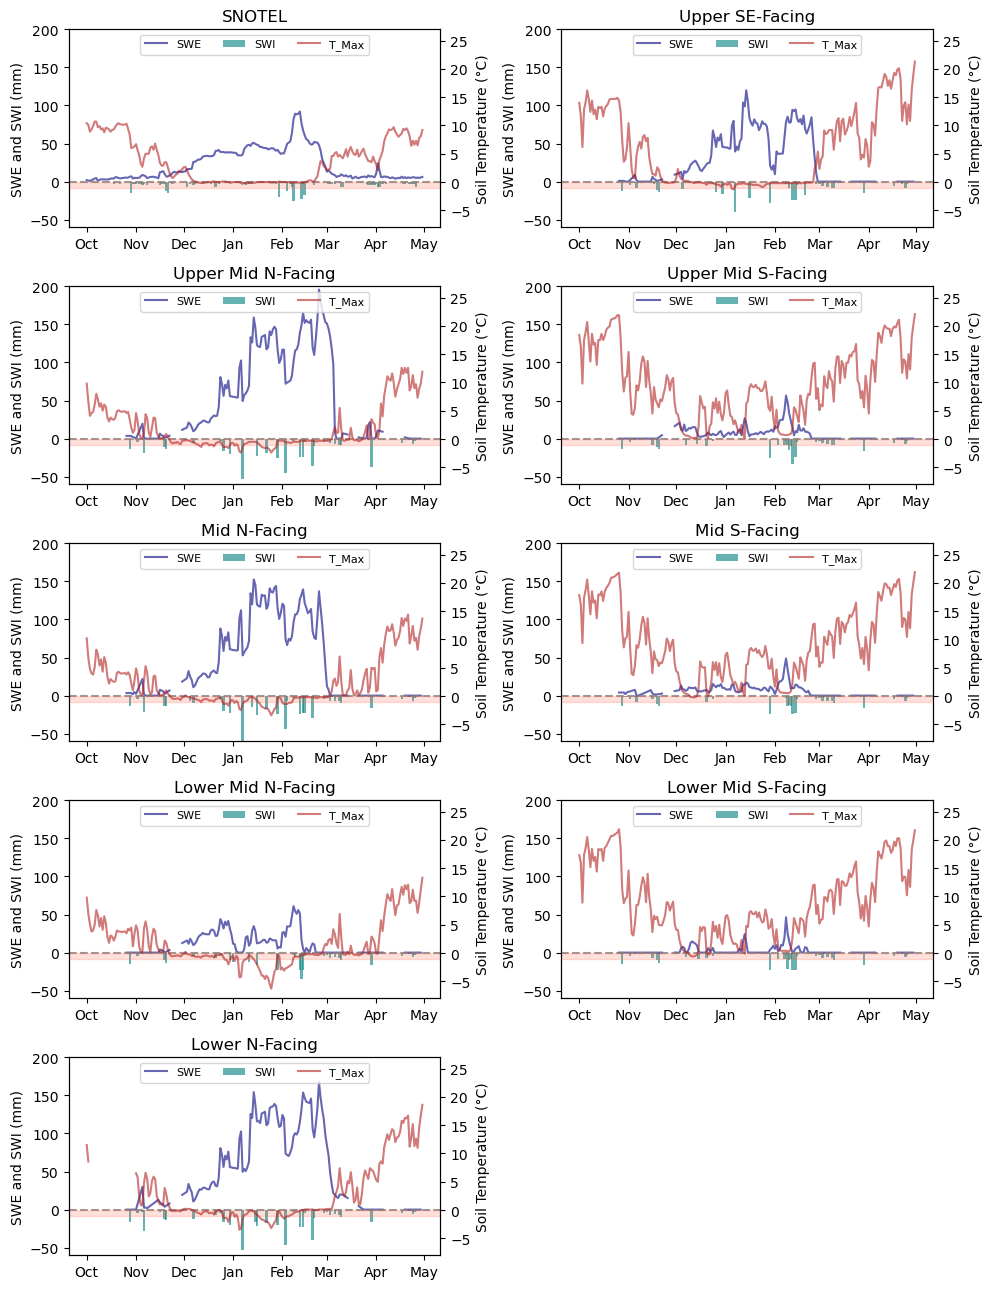

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_plot = df_daily[
    (df_daily["Date"] >= "2013-10-01") &
    (df_daily["Date"] <= "2014-04-30")
].copy()


panel_info = [
    {
        "left":  {"site":"ST",    "title":"SNOTEL", "swe": "SWE_ST_mm_interp", "swi":"SWI_ST_mm", "ts":"Ts_ST_max"},
        "right":  {"site":"124b",  "title":"Upper SE-Facing", "swe": "SWE_124b_mm", "swi":"SWI_124b_mm",  "ts":"Ts_124b_max"}
    },
    {
        "left":  {"site":"jdt4",  "title":"Upper Mid N-Facing", "swe": "SWE_jdt4_mm", "swi":"SWI_jdt4_mm",  "ts":"Ts_jdt4_max"},
        "right": {"site":"jdt4b", "title":"Upper Mid S-Facing", "swe": "SWE_jdt4b_mm", "swi":"SWI_jdt4b_mm", "ts":"Ts_jdt4b_max"}
    },
    {
        "left":  {"site":"jdt3",  "title":"Mid N-Facing", "swe": "SWE_jdt3_mm", "swi":"SWI_jdt3_mm",  "ts":"Ts_jdt3_max"},
        "right": {"site":"jdt3b", "title":"Mid S-Facing", "swe": "SWE_jdt3b_mm", "swi":"SWI_jdt3b_mm", "ts":"Ts_jdt3b_max"}
    },
    {
        "left":  {"site":"jdt2",  "title":"Lower Mid N-Facing", "swe": "SWE_jdt2_mm", "swi":"SWI_jdt2_mm",  "ts":"Ts_jdt2_max"},
        "right": {"site":"jdt2b", "title":"Lower Mid S-Facing", "swe": "SWE_jdt2b_mm", "swi":"SWI_jdt2b_mm", "ts":"Ts_jdt2b_max"}
    },
    {
        "left":  {"site":"jdt1",  "title":"Lower N-Facing", "swe": "SWE_jdt1_mm", "swi":"SWI_jdt1_mm",  "ts":"Ts_jdt1_max"},
        "right": None
    }
]

def plot_swi_temp_panel(ax, df_plot, swe_col, swi_col, ts_col, title,
                        swe_color="navy", swi_color="teal", ts_color="firebrick",
                        temp_threshold=-1.0,
                        swi_ylim=(-60, 200), ts_ylim=(-8, 27)):
    
    # left axis: SWI
    line_swe = ax.plot(df_plot["Date"], df_plot[swe_col], color=swe_color, label="SWE", alpha=0.6)[0]
    line_swi = ax.bar(df_plot["Date"], - df_plot[swi_col], color=swi_color, label="SWI", width=1.5, alpha=0.6)[0]
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel("SWE and SWI (mm)")
    ax.set_ylim(*swi_ylim)
    
    # right axis: soil temp
    ax2 = ax.twinx()
    line_ts = ax2.plot(df_plot["Date"], df_plot[ts_col], color=ts_color, label="T_Max", alpha=0.6)[0]
    ax2.axhspan(ymin=-1, ymax=0, color="tomato", alpha=0.2)
    ax2.set_ylabel("Soil Temperature (°C)")
    ax2.set_ylim(*ts_ylim)
    
    # date formatting
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.tick_params(labelbottom=True)
    
    # simple legend
    ax.legend([line_swe, line_swi, line_ts], ["SWE","SWI", "T_Max"], loc="upper center", ncol=3, fontsize=8)

# -----------------------------
# make figure
# -----------------------------
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 13), sharex=True)
axes = axes.flatten()

for row, info in enumerate(panel_info):
    left_ax = axes[row*2]
    right_ax = axes[row*2 + 1]
    
    # left panel
    left = info["left"]
    plot_swi_temp_panel(
        left_ax,
        df_plot,
        swe_col=left["swe"],
        swi_col=left["swi"],
        ts_col=left["ts"],
        title=left["title"]
    )
    
    # right panel
    if info["right"] is None:
        right_ax.set_visible(False)
    else:
        right = info["right"]
        plot_swi_temp_panel(
            right_ax,
            df_plot,
            swi_col=right["swi"],
            swe_col=right["swe"],
            ts_col=right["ts"],
            title=right["title"]
        )

plt.tight_layout()
plt.show()

In [26]:
def Mo_P_SWI_sum(df_daily, site):
    p_col = f"P_{site}_mm"
    swi_col = f"SWI_{site}_mm"

    # sanity check
    if p_col not in df_daily.columns or swi_col not in df_daily.columns:
        raise ValueError(f"Missing columns for site {site}")

    monthly = (
        df_daily.groupby(df_daily["Date"].dt.to_period("M"))[[p_col, swi_col]]
        .sum()
        .reset_index()
    )

    monthly = monthly.rename(columns={
        p_col: "P_mm",
        swi_col: "SWI_mm"
    })

    monthly["site"] = site
    return monthly

In [27]:
sites = ["124b", "jdt4", "jdt4b", "jdt3", "jdt3b", "jdt2", "jdt2b", "jdt1", "125"]

monthly_list = []

for site in sites:
    monthly = Mo_P_SWI_sum(df_daily, site)
    monthly_list.append(monthly)

df_MO = pd.concat(monthly_list, ignore_index=True)

In [28]:
df_MO[["P_mm", "SWI_mm"]] = df_MO[["P_mm", "SWI_mm"]].round(2)
df_MO.to_csv("monthly_P_SWI.csv", index=False)

In [29]:
df_daily.to_csv("Daily.csv", index=False)

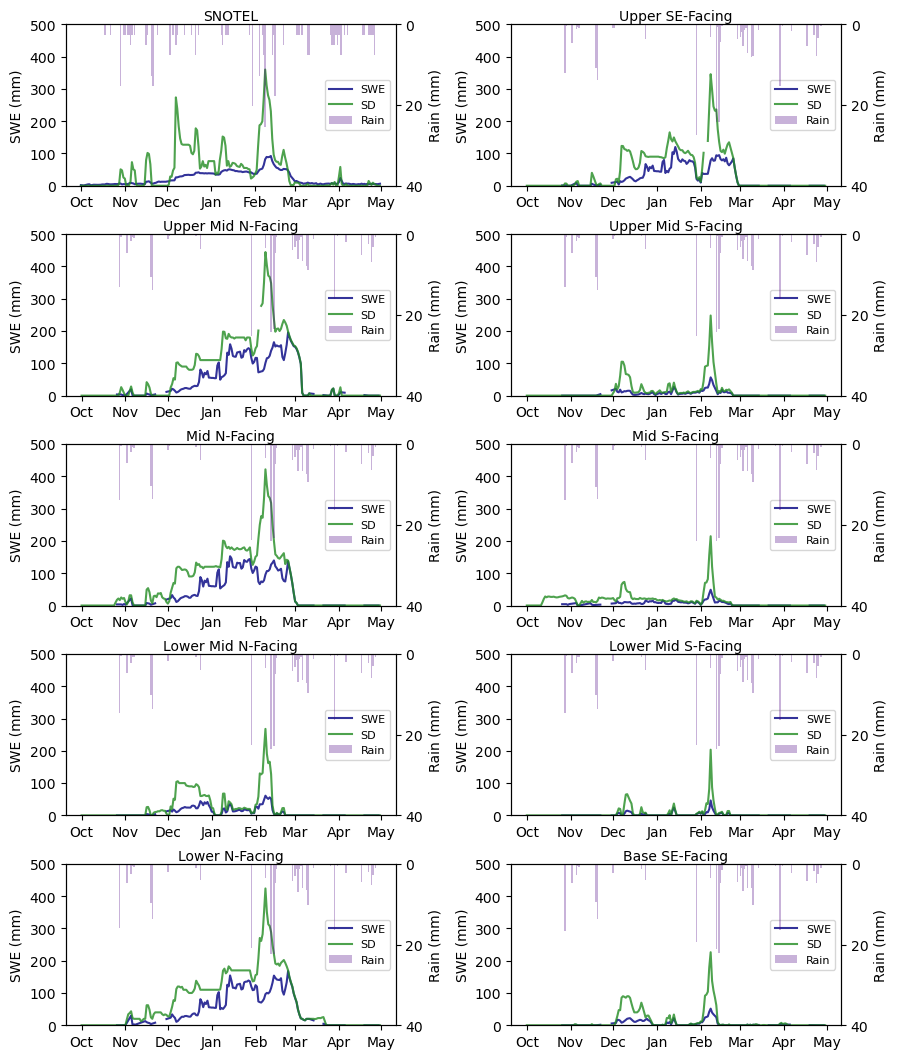

In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

# ---------- Map each site to its SWI column and soil moisture columns ----------
site_info = {
    "ST": {"name":"SNOTEL",
        "z": "z_s_ST_mm_interp",
        "swe" : "SWE_ST_mm_interp",
        "rain": "rain_ST_mm"
    },
    "124b": {"name":"Upper SE-Facing",
        "z": "z_s_124b_mm",
        "swe": "SWE_124b_mm",
        "rain": "rain_124b_mm"
    },
    "jdt4": {"name":"Upper Mid N-Facing",
        "z": "z_s_jdt4_mm",
        "swe": "SWE_jdt4_mm",
        "rain": "rain_jdt4_mm"
    },
    "jdt4b": {"name":"Upper Mid S-Facing",
        "z": "z_s_jdt4b_mm",
        "swe": "SWE_jdt4b_mm",
        "rain": "rain_jdt4b_mm"
    },
    "jdt3": {"name":"Mid N-Facing",
        "z": "z_s_jdt3_mm",
        "swe": "SWE_jdt3_mm",
        "rain": "rain_jdt3_mm"
    },
    "jdt3b": {"name":"Mid S-Facing",
        "z": "z_s_jdt3b_mm",
        "swe": "SWE_jdt3b_mm",
        "rain": "rain_jdt3b_mm"
    },
    "jdt2": {"name":"Lower Mid N-Facing",
        "z": "z_s_jdt2_mm",
        "swe": "SWE_jdt2_mm",
        "rain": "rain_jdt2_mm"
    },
    "jdt2b": {"name":"Lower Mid S-Facing",
        "z": "z_s_jdt2b_mm",
        "swe": "SWE_jdt2b_mm",
        "rain": "rain_jdt2b_mm"
    },
    "jdt1": {"name":"Lower N-Facing",
        "z": "z_s_jdt1_mm",
        "swe": "SWE_jdt1_mm",
        "rain": "rain_jdt1_mm"
    },
    "125": {"name": "Base SE-Facing",
        "z": "z_s_125_mm",
        "swe": "SWE_125_mm",
        "rain": "rain_125_mm"}
}


df_plot = df_daily[
    (df_daily["Date"] >= "2013-10-01") &
    (df_daily["Date"] <= "2014-04-30")
].copy()

panel_sites = [
    "ST", "124b",
    "jdt4", "jdt4b",
    "jdt3", "jdt3b",
    "jdt2", "jdt2b",
    "jdt1", "125"
]

nrows = 5
ncols = 2

fig = plt.figure(figsize=(10, 13))
outer = GridSpec(nrows=nrows, ncols=ncols, figure=fig, wspace=0.35, hspace=0.3)


for i, site in enumerate(panel_sites):
    row = i // 2
    col = i % 2

    if site is None:
        continue

    info = site_info[site]
    name = info["name"]
    z_col = info["z"]
    swe_col = info["swe"]
    rain_col = info["rain"]

    ax = fig.add_subplot(outer[row, col])


    # LEFT: z and SWE
    line_swe = ax.plot(
        df_plot["Date"], df_plot[swe_col],
        color="navy", alpha=0.8, linewidth=1.5, label="SWE"
    )[0]

    line_z = ax.plot(df_plot["Date"], df_plot[z_col], color="forestgreen", alpha=0.8, linewidth=1.5, label="SD")[0]
    ax.set_ylim(0, 500)
    ax.set_ylabel("SWE (mm)")
    ax.set_title(name, fontsize=10, pad=3)
    ax.tick_params(labelbottom=False)
    #ax.spines["bottom"].set_visible(False)

    # RIGHT: rain downward
    if rain_col is not None:
        ax2 = ax.twinx()
        bars_rain = ax2.bar(
            df_plot["Date"], df_plot[rain_col],
            color="indigo", width=1, alpha=0.3, label="Rain", zorder=-100
        )

        ax2.invert_yaxis()
        ax2.set_ylim(40, 0)
        ax2.set_yticks([0, 20, 40])
        ax2.set_ylabel("Rain (mm)")



    ax.tick_params(labelbottom=True)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    # --- after plotting SWE, z, and rain ---

    handles = []
    labels = []

    h1, l1 = ax.get_legend_handles_labels()
    handles += h1
    labels += l1

    if rain_col is not None:
        h2, l2 = ax2.get_legend_handles_labels()
        handles += h2
        labels += l2

    ax.legend(handles, labels, loc="center right", fontsize=8)



plt.show()